# **Модель, которая предсказывает мотив совершения преступления**

In [20]:
import re
import ast
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MultiLabelBinarizer,
    OneHotEncoder,
    StandardScaler
)

import optuna
from optuna import create_study
from optuna.importance import get_param_importances
from sklearn.multiclass import OneVsRestClassifier

from catboost import CatBoostClassifier
from collections import Counter
import networkx as nx

In [21]:
df = pd.read_csv('df_labeled_all_final_25.csv')

In [22]:
#df['has_man_victim'] = df['has_man_victim'].astype(int)
#df['has_woman_victim'] = df['has_man_victim'].astype(int)

In [23]:
df['motive'].value_counts()

motive
личная неприязнь                          34688
корысть, личная неприязнь                   935
корысть                                     610
другое                                      468
личная неприязнь, ревность                  310
                                          ...  
личная неприязнь, оскорбление, насилие        1
ссора, личная неприязнь                       1
ревность, месть, личная неприязнь             1
аморальное поведение потерпевшего             1
аморальность, противоправность                1
Name: count, Length: 117, dtype: int64

In [24]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
прочее                                    510
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
аморальность, личная неприязнь             16
месть                                      12
аморальность                               12
корысть, месть                              7
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, личная неприязнь, месть            3
личная неприязнь, месть, ревность           3
личная неприязнь, прочее                    3
аморальность, месть                         1
корысть, ревность                           1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [25]:
df["location"].value_counts()

location
жилое помещение                                                                                                                        27891
уличное пространство                                                                                                                    4430
жилое помещение, уличное пространство                                                                                                   1545
другое                                                                                                                                  1225
жилое помещение, подъезд и прилегающие зоны                                                                                              489
общественное место                                                                                                                       408
подъезд и прилегающие зоны                                                                                                               394
обще

In [26]:
df['location'] = df['location'].replace('другое', 'другая локация')

In [27]:
categorical = ['season', 'region_name','year']
#numeric = ['prison_term']
multilabel = ['method', 'location', 'motive']
other = ['gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

In [29]:
df['motive_'] = df['motive'].str.split(", ")
labels = df['motive'].tolist()
label_counts = Counter([label for sublist in labels for label in sublist])
for col in ['method', 'location']:
    df[col] = df[col].str.split(", ")
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_)
    col_df.index = df.index
    df = pd.concat([df, col_df], axis=1).drop(col, axis=1)


In [30]:
df["motive_"]

0                  [личная неприязнь]
1                  [личная неприязнь]
2         [корысть, личная неприязнь]
3         [корысть, личная неприязнь]
4                  [личная неприязнь]
                     ...             
37564              [личная неприязнь]
37565    [личная неприязнь, ревность]
37566                      [ревность]
37567              [личная неприязнь]
37568              [личная неприязнь]
Name: motive_, Length: 37569, dtype: object

In [31]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df
df = group_top_categories(df, 'judge', top_n=8, other_label='другое_судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое_регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое_год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()
df['region_name'].value_counts()

region_name
другое_регионы             26779
Московская область          1799
Свердловская область        1512
Республика Башкортостан     1506
Красноярский край           1331
Республика Бурятия          1232
Кемеровская область         1174
Краснодарский край          1150
Иркутская область           1086
Name: count, dtype: int64

In [32]:
df.head()

,id,judge,decision,gender_accused,prior_convictions,alcohol,precrime_argument,has_woman_victim,has_man_victim,motive,...,физическое воздействие,холодное оружие,другая локация,другое,жилое помещение,общественное место,общественный транспорт,подъезд и прилегающие зоны,рабочая зона,уличное пространство
0,92093,другое_судьи,Вынесен ПРИГОВОР,1,0,0,1,0,1,личная неприязнь,...,0,0,0,0,0,0,0,0,1,1
1,25775,другое_судьи,Вынесен ПРИГОВОР,1,0,0,0,0,1,личная неприязнь,...,0,1,0,0,0,1,0,0,0,1
2,75488,другое_судьи,Вынесен ПРИГОВОР,1,0,0,1,1,1,"корысть, личная неприязнь",...,1,1,0,0,1,0,0,0,0,0
3,126184,другое_судьи,Вынесен ПРИГОВОР,0,0,1,1,0,1,"корысть, личная неприязнь",...,0,0,0,0,0,0,0,0,0,1
4,102316,другое_судьи,Вынесен ПРИГОВОР,1,0,0,1,1,0,личная неприязнь,...,0,0,0,0,1,0,0,0,0,0


In [34]:
mlb1 = MultiLabelBinarizer()
col_binarized = mlb1.fit_transform(df['motive_'])

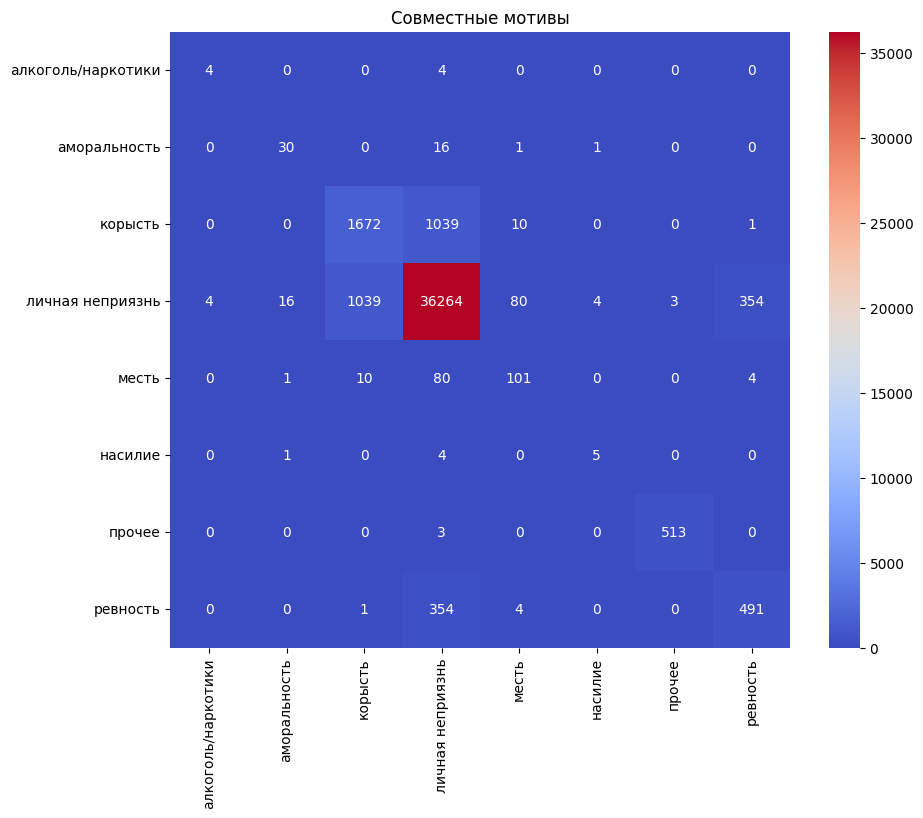

In [38]:
mlb = MultiLabelBinarizer()
labels = df['motive_'].tolist()
motive_col = mlb.fit_transform(labels)
co_occurrence = motive_col.T @ motive_col
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="coolwarm", 
            xticklabels=mlb.classes_, yticklabels=mlb.classes_)
plt.title("Совместные мотивы")
plt.show()

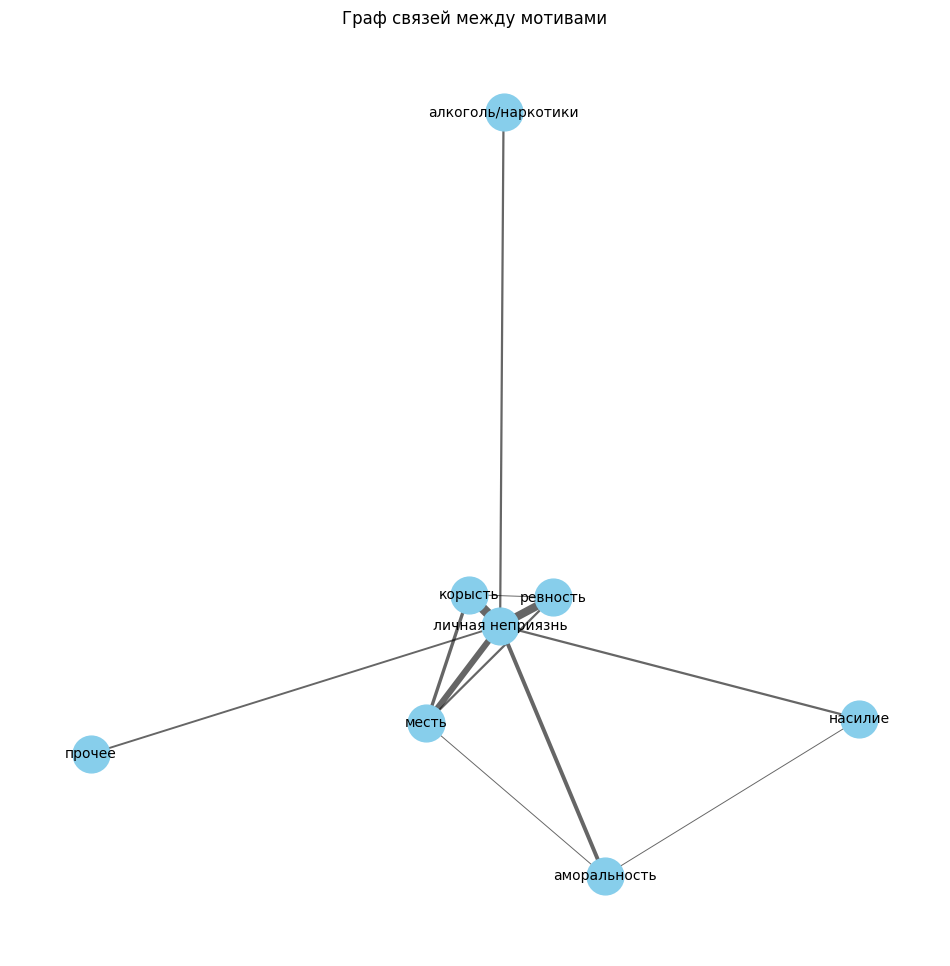

In [ ]:
G = nx.Graph()
for i, label_i in enumerate(mlb.classes_):
    for j, label_j in enumerate(mlb.classes_):
        if i < j and co_occurrence[i, j] > 0:
            G.add_edge(label_i, label_j, weight=co_occurrence[i, j])

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5, seed=42)
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, alpha=0.6,
                       width=[np.log1p(d['weight']) for (_, _, d) in edges])
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=10)
plt.title("Граф связей между мотивами")
plt.axis('off')
plt.show()


## **RandomForest**

In [40]:
target_ = 'motive'
categorical = ['season', 'year', 'region_name']
other_ = [
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'many_victims', 'attempt',
       'victim_child_or_helpless', 
       'огнестрельное оружие', 'тяжелые предметы', 'удушение',
       'физическое воздействие', 'холодное оружие',
       'жилое помещение', 'общественное место', 'общественный транспорт',
       'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'
]
selected_ = categorical + other_
mlb1 = MultiLabelBinarizer()
X = df[selected_]
y = mlb1.fit_transform(df["motive_"])

In [41]:
df["motive_"]

0                  [личная неприязнь]
1                  [личная неприязнь]
2         [корысть, личная неприязнь]
3         [корысть, личная неприязнь]
4                  [личная неприязнь]
                     ...             
37564              [личная неприязнь]
37565    [личная неприязнь, ревность]
37566                      [ревность]
37567              [личная неприязнь]
37568              [личная неприязнь]
Name: motive_, Length: 37569, dtype: object

In [42]:
X_trval, X_te, y_trval, y_te = train_test_split(X, y, test_size=0.1, random_state=42)
X_tr, X_val, y_tr, y_val = train_test_split(X_trval, y_trval, test_size=0.1, random_state=42)
preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical)
], remainder="passthrough")

X_tr_proc = preprocessor.fit_transform(X_tr)
X_val_proc = preprocessor.transform(X_val)
X_te_proc = preprocessor.transform(X_te)
feature_names = preprocessor.get_feature_names_out()
def optimize_rf(X_tr, y_tr, X_val, y_val, X_te, y_te):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 3, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "random_state": 42,
            "n_jobs": -1
        }
        model = OneVsRestClassifier(RandomForestClassifier(**params))
        model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        _, _, f1, _ = precision_recall_fscore_support(y_val, val_pred, average="micro", zero_division=0)
        return f1
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10)
    best_cfg = study.best_params
    print("Оптимальные параметры модели Random Forest:")
    print(best_cfg)
    final_model = OneVsRestClassifier(RandomForestClassifier(**best_cfg, random_state=42, n_jobs=-1))
    final_model.fit(np.vstack([X_tr, X_val]), np.vstack([y_tr, y_val]))
    y_pred = final_model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="micro", zero_division=0)
    print("\nРезультаты на тестовой выборке:")
    print(f"Точность: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-мера: {f1:.4f}")
    importances = np.mean([est.feature_importances_ for est in final_model.estimators_], axis=0)
    importance_df = pd.DataFrame({
        "Признак": feature_names,
        "Значимость": importances
    }).sort_values("Значимость", ascending=False)
    return final_model, importance_df

rf_model, rf_importances = optimize_rf(X_tr_proc, y_tr, X_val_proc, y_val, X_te_proc, y_te)

print("\nНаиболее значимые признаки (топ-10):")
print(rf_importances.head(10))


[I 2025-04-29 22:56:52,352] A new study created in memory with name: no-name-c7472fbf-e2e3-4893-9f39-176284ea207f
[I 2025-04-29 22:57:05,141] Trial 0 finished with value: 0.947521020585677 and parameters: {'n_estimators': 204, 'max_depth': 16, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.947521020585677.
[I 2025-04-29 22:57:48,879] Trial 1 finished with value: 0.947521020585677 and parameters: {'n_estimators': 705, 'max_depth': 29, 'min_samples_split': 20, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.947521020585677.
[I 2025-04-29 22:58:23,314] Trial 2 finished with value: 0.9472004641717435 and parameters: {'n_estimators': 645, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.947521020585677.
[I 2025-04-29 22:58:37,507] Trial 3 finished with value: 0.9478260869565217 and

Оптимальные параметры модели Random Forest:
{'n_estimators': 930, 'max_depth': 12, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': True}

Результаты на тестовой выборке:
Точность: 0.9244
Precision: 0.9610
Recall: 0.9286
F1-мера: 0.9445

Наиболее значимые признаки (топ-10):
                              Признак  Значимость
22                 remainder__alcohol    0.080884
23       remainder__precrime_argument    0.076728
32  remainder__физическое воздействие    0.054556
24        remainder__has_woman_victim    0.053765
25          remainder__has_man_victim    0.041419
27                 remainder__attempt    0.036368
33         remainder__холодное оружие    0.034383
7              categorical__year_2019    0.034086
2            categorical__season_Лето    0.029857
34         remainder__жилое помещение    0.029754


In [44]:
import joblib
joblib.dump(rf_model, "rf_model_motive.joblib")

['rf_model_motive.joblib']

In [43]:
rf_importances.tail(10)

,Признак,Значимость
14,categorical__region_name_Кемеровская область,0.013376
9,categorical__year_2021,0.013340
31,remainder__удушение,0.012706
36,remainder__общественный транспорт,0.011862
17,categorical__region_name_Московская область,0.011085
18,categorical__region_name_Республика Башкортостан,0.010975
13,categorical__region_name_Иркутская область,0.009750
37,remainder__подъезд и прилегающие зоны,0.009655
19,categorical__region_name_Республика Бурятия,0.009306
11,categorical__year_2023,0.008179
